<a href="https://colab.research.google.com/github/sanjanascorner/PyTorch-and-DeepLearning/blob/main/faster_rcnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import math
import random
import zipfile
import urllib.request
from collections import OrderedDict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.ops import roi_align, nms, box_iou
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

torch.manual_seed(0)
random.seed(0)
np.random.seed(0)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


In [ ]:
DATA_ROOT = "PennFudanPed"

if not os.path.exists(DATA_ROOT):
    url = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"
    zip_path = "PennFudanPed.zip"
    print("Downloading Penn-Fudan dataset...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(".")
    print("Done.")
else:
    print("Dataset already present.")


Done.


In [ ]:
class PennFudanDataset(Dataset):
    '''Each image has a matching PNG mask where every pedestrian instance is a
    distinct integer value (0 = background). We derive axis-aligned boxes from the
    masks so we don't need separate annotation files.'''

    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        self.imgs = sorted(os.listdir(os.path.join(root, "PNGImages")))
        self.masks = sorted(os.listdir(os.path.join(root, "PedMasks")))

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])

        img = Image.open(img_path).convert("RGB")
        mask = np.array(Image.open(mask_path))

        obj_ids = np.unique(mask)
        obj_ids = obj_ids[1:]  # drop background (0)

        boxes = []
        for oid in obj_ids:
            ys, xs = np.where(mask == oid)
            x1, x2 = xs.min(), xs.max()
            y1, y2 = ys.min(), ys.max()
            if x2 > x1 and y2 > y1:
                boxes.append([x1, y1, x2, y2])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.ones((boxes.shape[0],), dtype=torch.int64)  # single class: pedestrian

        img = torchvision.transforms.functional.to_tensor(img)

        target = {"boxes": boxes, "labels": labels}

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target


def collate_fn(batch):
    # Images can have different sizes, so we keep the batch as a list rather than
    # stacking into a single tensor.
    return tuple(zip(*batch))


full_dataset = PennFudanDataset(DATA_ROOT)
n_val = 20
indices = list(range(len(full_dataset)))
random.shuffle(indices)
train_idx, val_idx = indices[n_val:], indices[:n_val]

train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
val_dataset = torch.utils.data.Subset(full_dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

print(f"Train images: {len(train_dataset)} | Val images: {len(val_dataset)}")
img, tgt = full_dataset[0]
print("Example image shape:", img.shape, "| boxes:", tgt["boxes"].shape)


Train images: 150 | Val images: 20
Example image shape: torch.Size([3, 536, 559]) | boxes: torch.Size([2, 4])


In [ ]:
def box_area(boxes):
    return (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])


def encode_boxes(reference_boxes, proposals, weights=(1.0, 1.0, 1.0, 1.0)):
    '''Given anchor/proposal boxes and their matched ground-truth boxes, compute the
    (dx, dy, dw, dh) regression targets.'''
    wx, wy, ww, wh = weights

    ex_widths = proposals[:, 2] - proposals[:, 0]
    ex_heights = proposals[:, 3] - proposals[:, 1]
    ex_ctr_x = proposals[:, 0] + 0.5 * ex_widths
    ex_ctr_y = proposals[:, 1] + 0.5 * ex_heights

    gt_widths = reference_boxes[:, 2] - reference_boxes[:, 0]
    gt_heights = reference_boxes[:, 3] - reference_boxes[:, 1]
    gt_ctr_x = reference_boxes[:, 0] + 0.5 * gt_widths
    gt_ctr_y = reference_boxes[:, 1] + 0.5 * gt_heights

    targets_dx = wx * (gt_ctr_x - ex_ctr_x) / ex_widths
    targets_dy = wy * (gt_ctr_y - ex_ctr_y) / ex_heights
    targets_dw = ww * torch.log(gt_widths / ex_widths)
    targets_dh = wh * torch.log(gt_heights / ex_heights)

    return torch.stack([targets_dx, targets_dy, targets_dw, targets_dh], dim=1)


def decode_boxes(deltas, boxes, weights=(1.0, 1.0, 1.0, 1.0), bbox_xform_clip=math.log(1000.0 / 16)):
    '''Apply predicted (dx, dy, dw, dh) deltas to anchor/proposal boxes to get decoded
    boxes in (x1, y1, x2, y2) format.'''
    wx, wy, ww, wh = weights

    widths = boxes[:, 2] - boxes[:, 0]
    heights = boxes[:, 3] - boxes[:, 1]
    ctr_x = boxes[:, 0] + 0.5 * widths
    ctr_y = boxes[:, 1] + 0.5 * heights

    dx = deltas[:, 0::4] / wx
    dy = deltas[:, 1::4] / wy
    dw = deltas[:, 2::4] / ww
    dh = deltas[:, 3::4] / wh

    dw = torch.clamp(dw, max=bbox_xform_clip)
    dh = torch.clamp(dh, max=bbox_xform_clip)

    pred_ctr_x = dx * widths[:, None] + ctr_x[:, None]
    pred_ctr_y = dy * heights[:, None] + ctr_y[:, None]
    pred_w = torch.exp(dw) * widths[:, None]
    pred_h = torch.exp(dh) * heights[:, None]

    pred_boxes = torch.zeros_like(deltas)
    pred_boxes[:, 0::4] = pred_ctr_x - 0.5 * pred_w
    pred_boxes[:, 1::4] = pred_ctr_y - 0.5 * pred_h
    pred_boxes[:, 2::4] = pred_ctr_x + 0.5 * pred_w
    pred_boxes[:, 3::4] = pred_ctr_y + 0.5 * pred_h

    return pred_boxes


def clip_boxes_to_image(boxes, size):
    h, w = size
    boxes[:, 0::2] = boxes[:, 0::2].clamp(min=0, max=w)
    boxes[:, 1::2] = boxes[:, 1::2].clamp(min=0, max=h)
    return boxes


def remove_small_boxes(boxes, min_size):
    ws = boxes[:, 2] - boxes[:, 0]
    hs = boxes[:, 3] - boxes[:, 1]
    keep = (ws >= min_size) & (hs >= min_size)
    return torch.where(keep)[0]


In [ ]:
class AnchorGenerator(nn.Module):
    def __init__(self, sizes=(128, 256, 512), aspect_ratios=(0.5, 1.0, 2.0)):
        super().__init__()
        self.sizes = sizes
        self.aspect_ratios = aspect_ratios
        self.cell_anchors = self._generate_cell_anchors(sizes, aspect_ratios)

    def _generate_cell_anchors(self, sizes, aspect_ratios):
        anchors = []
        for size in sizes:
            area = size ** 2.0
            for ratio in aspect_ratios:
                w = math.sqrt(area / ratio)
                h = w * ratio
                anchors.append([-w / 2.0, -h / 2.0, w / 2.0, h / 2.0])
        return torch.tensor(anchors, dtype=torch.float32)

    def num_anchors_per_location(self):
        return len(self.sizes) * len(self.aspect_ratios)

    def forward(self, feature_map_size, stride, device):
        '''feature_map_size: (H, W) of the backbone feature map.
        stride: int, how many input pixels one feature-map cell corresponds to.
        Returns a (H*W*A, 4) tensor of anchor boxes in image coordinates.'''
        grid_h, grid_w = feature_map_size
        shifts_x = torch.arange(0, grid_w, device=device, dtype=torch.float32) * stride
        shifts_y = torch.arange(0, grid_h, device=device, dtype=torch.float32) * stride
        shift_y, shift_x = torch.meshgrid(shifts_y, shifts_x, indexing="ij")
        shift_x = shift_x.reshape(-1)
        shift_y = shift_y.reshape(-1)
        shifts = torch.stack([shift_x, shift_y, shift_x, shift_y], dim=1)  # (H*W, 4)

        cell_anchors = self.cell_anchors.to(device)

        anchors = (shifts.view(-1, 1, 4) + cell_anchors.view(1, -1, 4)).reshape(-1, 4)
        return anchors


In [ ]:
class Backbone(nn.Module):
    def __init__(self, out_channels=256):
        super().__init__()
        resnet = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2)
        self.body = nn.Sequential(OrderedDict([
            ("conv1", resnet.conv1),
            ("bn1", resnet.bn1),
            ("relu", resnet.relu),
            ("maxpool", resnet.maxpool),
            ("layer1", resnet.layer1),
            ("layer2", resnet.layer2),
            ("layer3", resnet.layer3),
            ("layer4", resnet.layer4),
        ]))
        self.stride = 32  # total downsampling from input to layer4 output
        self.reduce = nn.Conv2d(2048, out_channels, kernel_size=1)
        self.out_channels = out_channels

    def forward(self, x):
        feat = self.body(x)
        feat = self.reduce(feat)
        return feat


In [ ]:
class RPNHead(nn.Module):
    def __init__(self, in_channels, num_anchors):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        self.cls_logits = nn.Conv2d(in_channels, num_anchors, kernel_size=1)       # objectness
        self.bbox_pred = nn.Conv2d(in_channels, num_anchors * 4, kernel_size=1)    # deltas

        for l in [self.conv, self.cls_logits, self.bbox_pred]:
            nn.init.normal_(l.weight, std=0.01)
            nn.init.constant_(l.bias, 0)

    def forward(self, x):
        t = F.relu(self.conv(x))
        logits = self.cls_logits(t)   # (N, A, H, W)
        bbox_deltas = self.bbox_pred(t)  # (N, A*4, H, W)
        return logits, bbox_deltas


def permute_and_flatten(layer, N, A, C, H, W):
    layer = layer.view(N, A, C, H, W)
    layer = layer.permute(0, 3, 4, 1, 2)  # N, H, W, A, C
    layer = layer.reshape(N, -1, C)
    return layer


class RegionProposalNetwork(nn.Module):
    def __init__(self, anchor_generator, head,
                 fg_iou_thresh=0.7, bg_iou_thresh=0.3,
                 batch_size_per_image=256, positive_fraction=0.5,
                 pre_nms_top_n_train=2000, pre_nms_top_n_test=1000,
                 post_nms_top_n_train=1000, post_nms_top_n_test=300,
                 nms_thresh=0.7, min_size=1.0):
        super().__init__()
        self.anchor_generator = anchor_generator
        self.head = head
        self.fg_iou_thresh = fg_iou_thresh
        self.bg_iou_thresh = bg_iou_thresh
        self.batch_size_per_image = batch_size_per_image
        self.positive_fraction = positive_fraction
        self.pre_nms_top_n_train = pre_nms_top_n_train
        self.pre_nms_top_n_test = pre_nms_top_n_test
        self.post_nms_top_n_train = post_nms_top_n_train
        self.post_nms_top_n_test = post_nms_top_n_test
        self.nms_thresh = nms_thresh
        self.min_size = min_size

    def pre_nms_top_n(self):
        return self.pre_nms_top_n_train if self.training else self.pre_nms_top_n_test

    def post_nms_top_n(self):
        return self.post_nms_top_n_train if self.training else self.post_nms_top_n_test


    def assign_targets_to_anchors(self, anchors, gt_boxes):
        '''For one image: match each anchor to the ground-truth box it overlaps most
        with. Anchors are labelled 1 (foreground), 0 (background), or -1 (ignored,
        i.e. excluded from the loss) based on IoU thresholds.'''
        if gt_boxes.numel() == 0:
            labels = torch.zeros((anchors.shape[0],), dtype=torch.float32, device=anchors.device)
            matched_gt_boxes = torch.zeros_like(anchors)
            return labels, matched_gt_boxes

        iou = box_iou(gt_boxes, anchors)
        matched_vals, matched_idx = iou.max(dim=0)

        labels = torch.full((anchors.shape[0],), -1.0, dtype=torch.float32, device=anchors.device)
        labels[matched_vals >= self.fg_iou_thresh] = 1.0
        labels[matched_vals < self.bg_iou_thresh] = 0.0

        # Make sure every GT box has at least one positive anchor (the one with highest IoU).
        best_anchor_per_gt = iou.argmax(dim=1)
        labels[best_anchor_per_gt] = 1.0

        matched_gt_boxes = gt_boxes[matched_idx.clamp(min=0)]
        return labels, matched_gt_boxes

    def sample_anchors(self, labels):
        '''Subsample foreground/background anchors so the RPN loss is computed on a
        balanced mini-batch (paper uses 256 anchors, up to 50% positive).'''
        pos_idx = torch.where(labels == 1)[0]
        neg_idx = torch.where(labels == 0)[0]

        num_pos = int(self.batch_size_per_image * self.positive_fraction)
        num_pos = min(pos_idx.numel(), num_pos)
        num_neg = self.batch_size_per_image - num_pos
        num_neg = min(neg_idx.numel(), num_neg)

        perm_pos = pos_idx[torch.randperm(pos_idx.numel(), device=pos_idx.device)[:num_pos]]
        perm_neg = neg_idx[torch.randperm(neg_idx.numel(), device=neg_idx.device)[:num_neg]]
        return perm_pos, perm_neg

    def compute_loss(self, objectness, pred_bbox_deltas, labels, regression_targets, sampled_pos, sampled_neg):
        sampled_idx = torch.cat([sampled_pos, sampled_neg])

        objectness_loss = F.binary_cross_entropy_with_logits(
            objectness[sampled_idx], labels[sampled_idx]
        )

        if sampled_pos.numel() > 0:
            box_loss = F.smooth_l1_loss(
                pred_bbox_deltas[sampled_pos], regression_targets[sampled_pos],
                beta=1.0 / 9, reduction="sum"
            ) / sampled_idx.numel()
        else:
            box_loss = pred_bbox_deltas.sum() * 0.0

        return objectness_loss, box_loss
    def filter_proposals(self, proposals, scores, image_shape, num_anchors_per_level):
        N = proposals.shape[0]
        device = proposals.device

        top_n = min(self.pre_nms_top_n(), scores.shape[1])
        top_scores, top_idx = scores.topk(top_n, dim=1)
        batch_idx = torch.arange(N, device=device)[:, None]
        proposals = proposals[batch_idx, top_idx]

        final_boxes, final_scores = [], []
        for boxes, sc in zip(proposals, top_scores):
            boxes = clip_boxes_to_image(boxes, image_shape)
            keep = remove_small_boxes(boxes, self.min_size)
            boxes, sc = boxes[keep], sc[keep]
            keep = nms(boxes, sc, self.nms_thresh)
            keep = keep[: self.post_nms_top_n()]
            final_boxes.append(boxes[keep])
            final_scores.append(sc[keep])
        return final_boxes, final_scores

    def forward(self, features, image_shapes, targets=None):
        objectness, pred_bbox_deltas = self.head(features)
        N, A_times_4, H, W = pred_bbox_deltas.shape
        A = A_times_4 // 4

        anchors_per_image = self.anchor_generator((H, W), self.anchor_generator_stride, features.device)
        anchors = [anchors_per_image for _ in range(N)]  # same grid for every image in the batch

        objectness = permute_and_flatten(objectness, N, A, 1, H, W).reshape(N, -1)
        pred_bbox_deltas = permute_and_flatten(pred_bbox_deltas, N, A, 4, H, W)

        decoded_proposals = []
        for i in range(N):
            decoded = decode_boxes(pred_bbox_deltas[i].reshape(-1, 4).detach(), anchors[i])
            decoded_proposals.append(decoded.reshape(-1, 4))
        decoded_proposals = torch.stack(decoded_proposals, dim=0)

        boxes, scores = self.filter_proposals(decoded_proposals, objectness.detach(), image_shapes[0], None)

        losses = {}
        if self.training:
            assert targets is not None
            all_labels, all_reg_targets = [], []
            for i in range(N):
                labels, matched_gt = self.assign_targets_to_anchors(anchors[i], targets[i]["boxes"])
                reg_targets = encode_boxes(matched_gt, anchors[i])
                all_labels.append(labels)
                all_reg_targets.append(reg_targets)

            labels = torch.cat(all_labels)
            reg_targets = torch.cat(all_reg_targets)
            flat_objectness = objectness.reshape(-1)
            flat_deltas = pred_bbox_deltas.reshape(-1, 4)

            pos_idx, neg_idx = self.sample_anchors(labels)
            loss_objectness, loss_rpn_box_reg = self.compute_loss(
                flat_objectness, flat_deltas, labels, reg_targets, pos_idx, neg_idx
            )
            losses = {"loss_objectness": loss_objectness, "loss_rpn_box_reg": loss_rpn_box_reg}

        return boxes, scores, losses


In [ ]:
class ROIHeads(nn.Module):
    def __init__(self, in_channels, roi_output_size, num_classes,
                 fg_iou_thresh=0.5, bg_iou_thresh=0.5,
                 batch_size_per_image=128, positive_fraction=0.25,
                 score_thresh=0.05, nms_thresh=0.5, detections_per_img=100):
        super().__init__()
        self.roi_output_size = roi_output_size
        self.num_classes = num_classes  # includes background as class 0
        self.fg_iou_thresh = fg_iou_thresh
        self.bg_iou_thresh = bg_iou_thresh
        self.batch_size_per_image = batch_size_per_image
        self.positive_fraction = positive_fraction
        self.score_thresh = score_thresh
        self.nms_thresh = nms_thresh
        self.detections_per_img = detections_per_img

        flat_dim = in_channels * roi_output_size * roi_output_size
        self.fc6 = nn.Linear(flat_dim, 1024)
        self.fc7 = nn.Linear(1024, 1024)
        self.cls_score = nn.Linear(1024, num_classes)
        self.bbox_pred = nn.Linear(1024, num_classes * 4)

        for l in [self.fc6, self.fc7]:
            nn.init.kaiming_uniform_(l.weight, a=1)
            nn.init.constant_(l.bias, 0)
        nn.init.normal_(self.cls_score.weight, std=0.01)
        nn.init.constant_(self.cls_score.bias, 0)
        nn.init.normal_(self.bbox_pred.weight, std=0.001)
        nn.init.constant_(self.bbox_pred.bias, 0)

    def assign_targets_to_proposals(self, proposals, gt_boxes, gt_labels):
        if gt_boxes.numel() == 0:
            labels = torch.zeros((proposals.shape[0],), dtype=torch.int64, device=proposals.device)
            matched_gt_boxes = torch.zeros_like(proposals)
            return labels, matched_gt_boxes

        iou = box_iou(gt_boxes, proposals)
        matched_vals, matched_idx = iou.max(dim=0)

        labels = gt_labels[matched_idx].clone()
        labels[matched_vals < self.fg_iou_thresh] = 0  # background
        ignore = (matched_vals >= self.bg_iou_thresh) & (matched_vals < self.fg_iou_thresh)
        labels[ignore] = 0  # simple 2-threshold version: treat as background

        matched_gt_boxes = gt_boxes[matched_idx]
        return labels, matched_gt_boxes

    def sample_proposals(self, labels):
        pos_idx = torch.where(labels > 0)[0]
        neg_idx = torch.where(labels == 0)[0]

        num_pos = int(self.batch_size_per_image * self.positive_fraction)
        num_pos = min(pos_idx.numel(), num_pos)
        num_neg = self.batch_size_per_image - num_pos
        num_neg = min(neg_idx.numel(), num_neg)

        perm_pos = pos_idx[torch.randperm(pos_idx.numel(), device=pos_idx.device)[:num_pos]]
        perm_neg = neg_idx[torch.randperm(neg_idx.numel(), device=neg_idx.device)[:num_neg]]
        return torch.cat([perm_pos, perm_neg])

    def pool_features(self, features, boxes_per_image, image_shape, spatial_scale):
        '''boxes_per_image: list of (Ni, 4) tensors, one per image (in image coords).'''
        rois = []
        for i, boxes in enumerate(boxes_per_image):
            idx = torch.full((boxes.shape[0], 1), i, dtype=boxes.dtype, device=boxes.device)
            rois.append(torch.cat([idx, boxes], dim=1))
        rois = torch.cat(rois, dim=0)
        pooled = roi_align(features, rois, output_size=self.roi_output_size,
                            spatial_scale=spatial_scale, sampling_ratio=2)
        return pooled

    def forward(self, features, proposals, image_shape, spatial_scale, targets=None):
        device = features.device

        if self.training:
            assert targets is not None
            all_proposals, all_labels, all_reg_targets = [], [], []
            for props, tgt in zip(proposals, targets):
                gt_boxes, gt_labels = tgt["boxes"], tgt["labels"]
                # Include GT boxes themselves as proposals so there's always something
                # to learn positives from, as in the original implementation.
                props = torch.cat([props, gt_boxes], dim=0)
                labels, matched_gt = self.assign_targets_to_proposals(props, gt_boxes, gt_labels)
                keep = self.sample_proposals(labels)
                props, labels, matched_gt = props[keep], labels[keep], matched_gt[keep]

                reg_targets = torch.zeros((props.shape[0], 4), device=device)
                pos_mask = labels > 0
                if pos_mask.any():
                    reg_targets[pos_mask] = encode_boxes(matched_gt[pos_mask], props[pos_mask])

                all_proposals.append(props)
                all_labels.append(labels)
                all_reg_targets.append(reg_targets)
            proposals = all_proposals

        pooled = self.pool_features(features, proposals, image_shape, spatial_scale)
        x = pooled.flatten(start_dim=1)
        x = F.relu(self.fc6(x))
        x = F.relu(self.fc7(x))
        class_logits = self.cls_score(x)
        box_deltas = self.bbox_pred(x)

        losses = {}
        detections = []

        if self.training:
            labels = torch.cat(all_labels)
            reg_targets = torch.cat(all_reg_targets)

            loss_classifier = F.cross_entropy(class_logits, labels)

            pos_idx = torch.where(labels > 0)[0]
            if pos_idx.numel() > 0:
                box_deltas_reshaped = box_deltas.view(-1, self.num_classes, 4)
                pos_labels = labels[pos_idx]
                pos_box_deltas = box_deltas_reshaped[pos_idx, pos_labels]
                loss_box_reg = F.smooth_l1_loss(pos_box_deltas, reg_targets[pos_idx],
                                                 beta=1.0, reduction="sum") / labels.numel()
            else:
                loss_box_reg = box_deltas.sum() * 0.0

            losses = {"loss_classifier": loss_classifier, "loss_box_reg": loss_box_reg}
        else:
            boxes_per_image = [p.shape[0] for p in proposals]
            class_logits_split = class_logits.split(boxes_per_image, dim=0)
            box_deltas_split = box_deltas.split(boxes_per_image, dim=0)

            for props, logits, deltas in zip(proposals, class_logits_split, box_deltas_split):
                probs = F.softmax(logits, dim=-1)
                deltas = deltas.view(-1, self.num_classes, 4)

                image_boxes, image_scores, image_labels = [], [], []
                for cls in range(1, self.num_classes):
                    cls_scores = probs[:, cls]
                    cls_deltas = deltas[:, cls]
                    cls_boxes = decode_boxes(cls_deltas, props)
                    cls_boxes = clip_boxes_to_image(cls_boxes.view(-1, 4), image_shape)

                    keep = cls_scores > self.score_thresh
                    cls_boxes, cls_scores_k = cls_boxes[keep], cls_scores[keep]
                    if cls_boxes.numel() == 0:
                        continue
                    keep_nms = nms(cls_boxes, cls_scores_k, self.nms_thresh)
                    image_boxes.append(cls_boxes[keep_nms])
                    image_scores.append(cls_scores_k[keep_nms])
                    image_labels.append(torch.full((keep_nms.numel(),), cls, dtype=torch.int64, device=device))

                if len(image_boxes) > 0:
                    image_boxes = torch.cat(image_boxes)
                    image_scores = torch.cat(image_scores)
                    image_labels = torch.cat(image_labels)
                    if image_boxes.shape[0] > self.detections_per_img:
                        top = image_scores.topk(self.detections_per_img).indices
                        image_boxes, image_scores, image_labels = image_boxes[top], image_scores[top], image_labels[top]
                else:
                    image_boxes = torch.zeros((0, 4), device=device)
                    image_scores = torch.zeros((0,), device=device)
                    image_labels = torch.zeros((0,), dtype=torch.int64, device=device)

                detections.append({"boxes": image_boxes, "scores": image_scores, "labels": image_labels})

        return detections, losses


In [ ]:
class FasterRCNN(nn.Module):
    def __init__(self, num_classes, anchor_sizes=(64, 128, 256), aspect_ratios=(0.5, 1.0, 2.0),
                 roi_output_size=7):
        super().__init__()
        self.backbone = Backbone(out_channels=256)
        self.anchor_generator = AnchorGenerator(sizes=anchor_sizes, aspect_ratios=aspect_ratios)
        num_anchors = self.anchor_generator.num_anchors_per_location()
        rpn_head = RPNHead(self.backbone.out_channels, num_anchors)

        self.rpn = RegionProposalNetwork(self.anchor_generator, rpn_head)
        self.rpn.anchor_generator_stride = self.backbone.stride

        # num_classes passed in should NOT include background; the head adds it.
        self.roi_heads = ROIHeads(self.backbone.out_channels, roi_output_size, num_classes + 1)

        # Fixed image size for this simple implementation: images are resized so the
        # shorter side is `min_size`, capped at `max_size` on the longer side.
        self.min_size = 600
        self.max_size = 1000

    def resize_image(self, image, target=None):
        _, h, w = image.shape
        scale = self.min_size / min(h, w)
        if max(h, w) * scale > self.max_size:
            scale = self.max_size / max(h, w)
        new_h, new_w = int(h * scale), int(w * scale)
        image = F.interpolate(image[None], size=(new_h, new_w), mode="bilinear", align_corners=False)[0]
        if target is not None:
            target = dict(target)
            target["boxes"] = target["boxes"] * scale
        return image, target, scale

    def forward(self, images, targets=None):
        if self.training:
            assert targets is not None

        resized, resized_targets, scales = [], [], []
        for i, img in enumerate(images):
            tgt = targets[i] if targets is not None else None
            img_r, tgt_r, scale = self.resize_image(img, tgt)
            resized.append(img_r)
            resized_targets.append(tgt_r)
            scales.append(scale)

        # Pad to a common size so we can batch them into one tensor.
        max_h = max(im.shape[1] for im in resized)
        max_w = max(im.shape[2] for im in resized)
        batched = torch.zeros((len(resized), 3, max_h, max_w), device=resized[0].device)
        for i, im in enumerate(resized):
            batched[i, :, : im.shape[1], : im.shape[2]] = im
        image_shape = (max_h, max_w)

        features = self.backbone(batched)
        spatial_scale = 1.0 / self.backbone.stride

        proposals, _, rpn_losses = self.rpn(features, [image_shape], resized_targets if self.training else None)
        detections, roi_losses = self.roi_heads(
            features, proposals, image_shape, spatial_scale,
            resized_targets if self.training else None
        )

        if self.training:
            losses = {}
            losses.update(rpn_losses)
            losses.update(roi_losses)
            return losses
        for det, scale in zip(detections, scales):
            det["boxes"] = det["boxes"] / scale
        return detections


In [ ]:
NUM_CLASSES = 1  # pedestrian (background is handled internally as class 0)

model = FasterRCNN(num_classes=NUM_CLASSES).to(DEVICE)
print(model)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 137MB/s]


FasterRCNN(
  (backbone): Backbone(
    (body): Sequential(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_r

In [ ]:
def train_one_epoch(model, optimizer, data_loader, device, epoch, print_every=10):
    model.train()
    total_loss = 0.0
    for step, (images, targets) in enumerate(data_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()
        if step % print_every == 0:
            loss_str = " | ".join(f"{k}: {v.item():.4f}" for k, v in loss_dict.items())
            print(f"Epoch {epoch} step {step}/{len(data_loader)} | total: {loss.item():.4f} | {loss_str}")

    return total_loss / len(data_loader)


params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=6, gamma=0.1)

NUM_EPOCHS = 8

for epoch in range(NUM_EPOCHS):
    avg_loss = train_one_epoch(model, optimizer, train_loader, DEVICE, epoch)
    lr_scheduler.step()
    print(f"=== Epoch {epoch} finished | avg loss: {avg_loss:.4f} ===\n")


Epoch 0 step 0/75 | total: 1.4118 | loss_objectness: 0.6926 | loss_rpn_box_reg: 0.0166 | loss_classifier: 0.6980 | loss_box_reg: 0.0047
Epoch 0 step 10/75 | total: 1.0228 | loss_objectness: 0.6796 | loss_rpn_box_reg: 0.0082 | loss_classifier: 0.3303 | loss_box_reg: 0.0047
Epoch 0 step 20/75 | total: 0.9453 | loss_objectness: 0.6546 | loss_rpn_box_reg: 0.0105 | loss_classifier: 0.2772 | loss_box_reg: 0.0030
Epoch 0 step 30/75 | total: 0.9851 | loss_objectness: 0.6292 | loss_rpn_box_reg: 0.0102 | loss_classifier: 0.3391 | loss_box_reg: 0.0067
Epoch 0 step 40/75 | total: 1.0805 | loss_objectness: 0.6005 | loss_rpn_box_reg: 0.0090 | loss_classifier: 0.4619 | loss_box_reg: 0.0091
Epoch 0 step 50/75 | total: 0.8830 | loss_objectness: 0.5559 | loss_rpn_box_reg: 0.0225 | loss_classifier: 0.2967 | loss_box_reg: 0.0079
Epoch 0 step 60/75 | total: 0.9246 | loss_objectness: 0.4926 | loss_rpn_box_reg: 0.0102 | loss_classifier: 0.4145 | loss_box_reg: 0.0073
Epoch 0 step 70/75 | total: 0.6423 | loss_

Found 2 detections above threshold


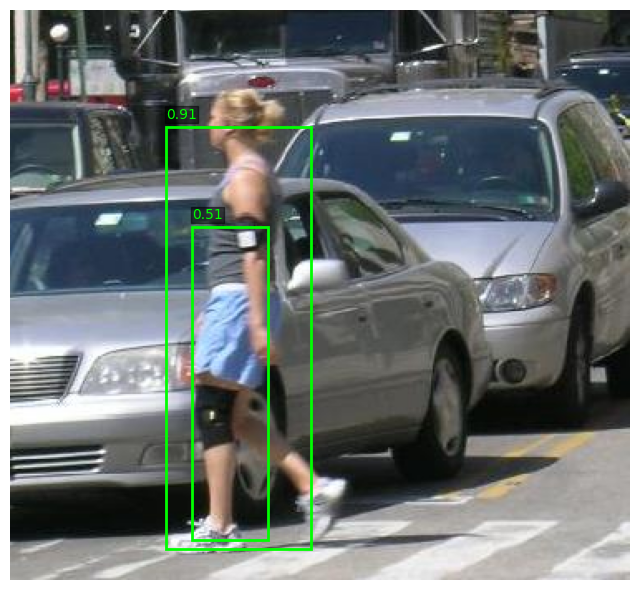

In [ ]:
@torch.no_grad()
def predict(model, image, device, score_thresh=0.5):
    model.eval()
    image = image.to(device)
    detections = model([image])[0]
    keep = detections["scores"] > score_thresh
    return {k: v[keep].cpu() for k, v in detections.items()}


def show_prediction(image, detections, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, figsize=(8, 8))
    img_np = image.permute(1, 2, 0).cpu().numpy()
    ax.imshow(img_np)
    for box, score in zip(detections["boxes"], detections["scores"]):
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2,
                                  edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, max(y1 - 5, 0), f"{score:.2f}", color="lime", fontsize=10,
                 bbox=dict(facecolor="black", alpha=0.5, pad=1))
    ax.axis("off")
    return ax


img, target = val_dataset[0]
detections = predict(model, img, DEVICE, score_thresh=0.5)
print(f"Found {len(detections['boxes'])} detections above threshold")
show_prediction(img, detections)
plt.show()


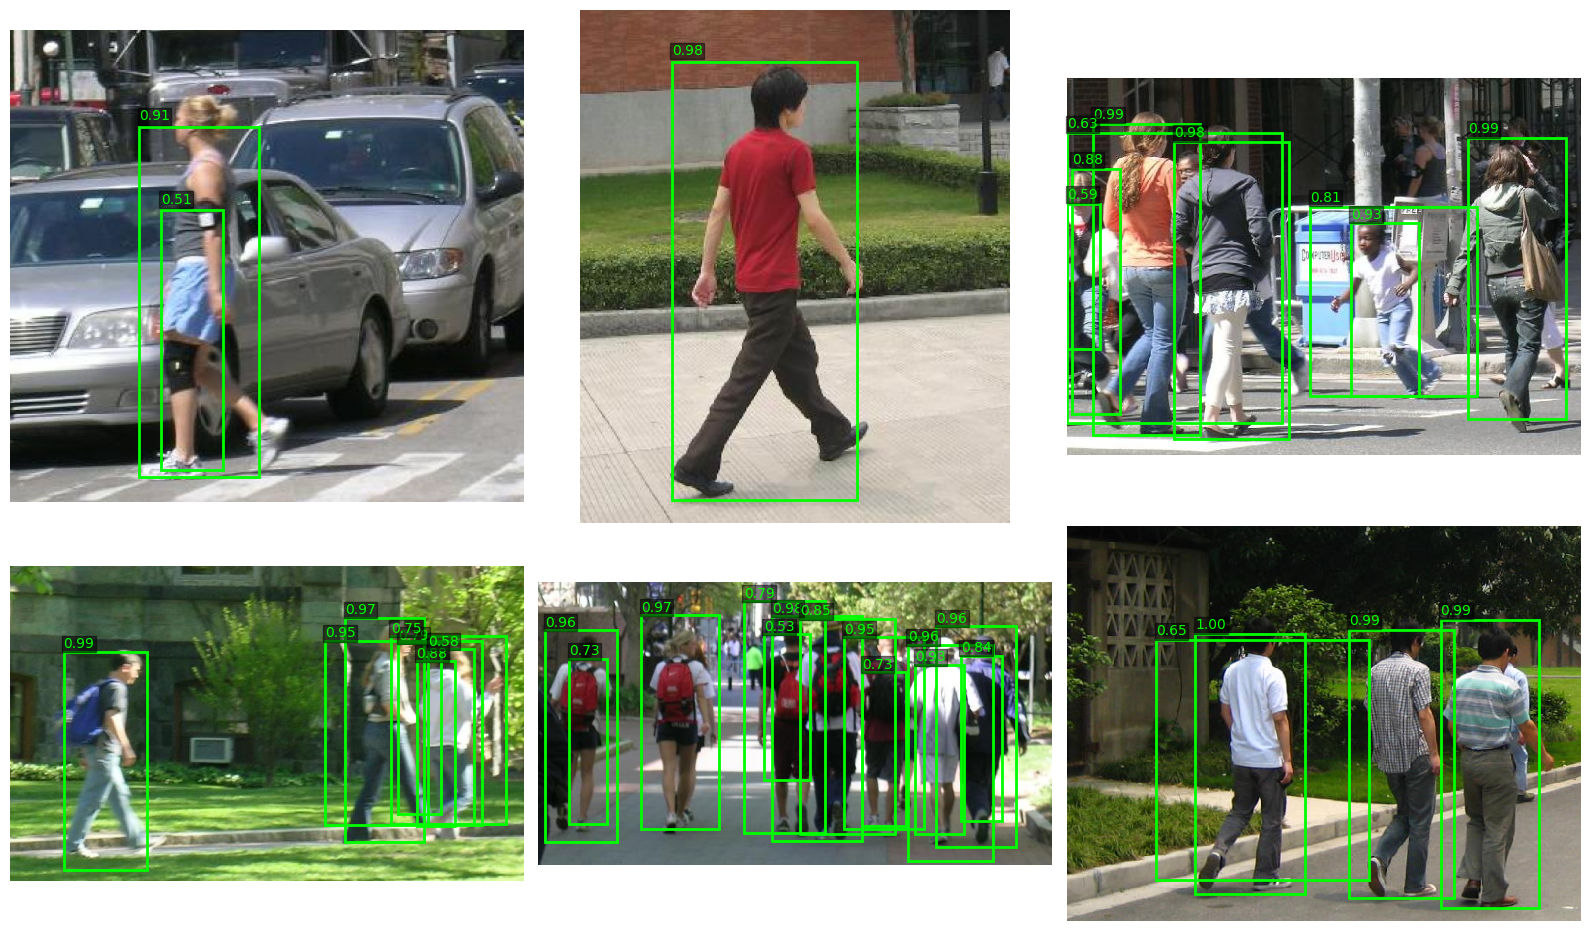

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, idx in zip(axes.flatten(), range(min(6, len(val_dataset)))):
    img, target = val_dataset[idx]
    detections = predict(model, img, DEVICE, score_thresh=0.5)
    show_prediction(img, detections, ax=ax)
plt.tight_layout()
plt.show()


In [ ]:
torch.save(model.state_dict(), "faster_rcnn_scratch.pth")
print("Saved to faster_rcnn_scratch.pth")


Saved to faster_rcnn_scratch.pth
